# Prototipagem e teste da classe de geração de Histograma de Resíduos

### Imports:

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

### 1. Definição da classe:

Protótipo da classe `PredictionErrorAnalyzer`, que espera uma entrada `(n_windows, window_size, n_variables)` e gera o histograma de resíduos e histograma de MSE associado a cada janela.

In [24]:
class PredictionErrorAnalyzer:
    """
    Calcula e analisa os erros entre os valores reais
    e as previsões do MOMENT.

    Entrada esperada:
        (n_windows, window_size, n_variables)

    Calcula:
        - resíduos ponto a ponto
        - MSE por janela

    Permite:
        - obter os resíduos
        - obter os MSEs
        - calcular estatísticas dos MSEs
        - plotar o histograma dos resíduos
        - plotar o histograma dos MSEs por janela
        - salvar os histogramas em arquivo
    """

    def __init__(self, y_true, y_pred):
        self.y_true = np.asarray(
            y_true,
            dtype=np.float32,
        )

        self.y_pred = np.asarray(
            y_pred,
            dtype=np.float32,
        )

        self._validate_inputs()

        self.residuals = self._calculate_residuals()
        self.mse = self._calculate_mse()

    def _validate_inputs(self):
        if self.y_true.ndim != 3:
            raise ValueError(
                "y_true deve possuir 3 dimensões: "
                "(n_windows, window_size, n_variables). "
                f"Shape recebido: {self.y_true.shape}"
            )

        if self.y_pred.ndim != 3:
            raise ValueError(
                "y_pred deve possuir 3 dimensões: "
                "(n_windows, window_size, n_variables). "
                f"Shape recebido: {self.y_pred.shape}"
            )

        if self.y_true.shape != self.y_pred.shape:
            raise ValueError(
                "y_true e y_pred devem possuir o mesmo shape. "
                f"y_true={self.y_true.shape}, "
                f"y_pred={self.y_pred.shape}"
            )

        if not np.isfinite(self.y_true).all():
            raise ValueError(
                "y_true contém NaN ou Inf."
            )

        if not np.isfinite(self.y_pred).all():
            raise ValueError(
                "y_pred contém NaN ou Inf."
            )

    def _calculate_residuals(self):
        """
        Calcula os resíduos ponto a ponto.

        Resíduo:
            y_true - y_pred

        Mantém o mesmo shape da entrada:
            (n_windows, window_size, n_variables)
        """

        residuals = (
            self.y_true - self.y_pred
        )

        return residuals.astype(np.float32)

    def _calculate_mse(self):
        """
        Calcula um MSE para cada janela.

        O erro é calculado sobre:
            - todos os pontos temporais
            - todas as variáveis

        Retorna:
            (n_windows,)
        """

        squared_error = (
            self.residuals ** 2
        )

        mse = squared_error.mean(
            axis=(1, 2)
        )

        return mse.astype(np.float32)

    def get_residuals(self):
        """
        Retorna os resíduos ponto a ponto.

        Shape:
            (n_windows, window_size, n_variables)
        """

        return self.residuals.copy()

    def get_mse(self):
        """
        Retorna o MSE de cada janela.

        Shape:
            (n_windows,)
        """

        return self.mse.copy()

    def statistics(self):
        """
        Retorna estatísticas da distribuição
        dos MSEs por janela.
        """

        return pd.Series(
            self.mse,
            name="mse",
        ).describe()

    def plot_residual_histogram(
        self,
        bins=50,
        figsize=(10, 5),
        save_path=None,
    ):
        """
        Gera o histograma dos resíduos.

        Todos os resíduos de todas as janelas,
        pontos temporais e variáveis são considerados.

        O eixo horizontal representa o resíduo:
            y_true - y_pred

        Portanto, o centro esperado para uma distribuição
        sem viés é zero.

        Parâmetros:
            bins:
                Número de bins do histograma.

            figsize:
                Tamanho da figura.

            save_path:
                Caminho onde a imagem será salva.
                Se None, a imagem não será salva.

        O gráfico é mostrado na tela.
        """

        if self.residuals.size == 0:
            raise ValueError(
                "Nenhum resíduo disponível para plotar."
            )

        plt.figure(figsize=figsize)

        plt.hist(
            self.residuals.ravel(),
            bins=bins,
        )

        plt.axvline(
            0,
            linestyle="--",
            linewidth=1,
        )

        plt.xlabel(
            "Resíduo (real - previsão)"
        )

        plt.ylabel(
            "Frequência"
        )

        plt.title(
            "Histograma dos resíduos da previsão"
        )

        plt.grid(
            alpha=0.2
        )

        plt.tight_layout()

        if save_path is not None:
            save_path = Path(save_path)
            save_path.parent.mkdir(
                parents=True,
                exist_ok=True,
            )

            plt.savefig(
                save_path,
                bbox_inches="tight",
            )

        plt.show()
        plt.close()

    def plot_mse_histogram(
        self,
        bins=50,
        figsize=(10, 5),
        save_path=None,
    ):
        """
        Gera o histograma dos MSEs por janela.

        Cada observação do histograma corresponde
        a uma janela.

        Parâmetros:
            bins:
                Número de bins do histograma.

            figsize:
                Tamanho da figura.

            save_path:
                Caminho onde a imagem será salva.
                Se None, a imagem não será salva.

        O gráfico é mostrado na tela.
        """

        if len(self.mse) == 0:
            raise ValueError(
                "Nenhum MSE disponível para plotar."
            )

        plt.figure(figsize=figsize)

        plt.hist(
            self.mse,
            bins=bins,
        )

        plt.xlabel(
            "Erro médio quadrático (MSE)"
        )

        plt.ylabel(
            "Número de janelas"
        )

        plt.title(
            "Distribuição do MSE por janela"
        )

        plt.grid(
            alpha=0.2
        )

        plt.tight_layout()

        if save_path is not None:
            save_path = Path(save_path)
            save_path.parent.mkdir(
                parents=True,
                exist_ok=True,
            )

            plt.savefig(
                save_path,
                bbox_inches="tight",
            )

        plt.show()
        plt.close()


### 2. Simulação
##### 2.1. Criação dos dados simulados:

In [25]:
N_WINDOWS = 1000
WINDOW_SIZE = 128
N_VARIABLES = 17

rng = np.random.default_rng(42)

y_true = rng.normal(
    loc=0.0,
    scale=1.0,
    size=(
        N_WINDOWS,
        WINDOW_SIZE,
        N_VARIABLES,
    ),
).astype(np.float32)

noise = rng.normal(
    loc=0.0,
    scale=0.1,
    size=y_true.shape,
).astype(np.float32)

y_pred = y_true + noise

print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)

y_true: (1000, 128, 17)
y_pred: (1000, 128, 17)


##### 2.2 Instanciando classe e obtendo resíduos:

In [26]:
error_analyzer = PredictionErrorAnalyzer(
    y_true=y_true,
    y_pred=y_pred,
)

print(
    "[OK] PredictionErrorAnalyzer criado."
)

[OK] PredictionErrorAnalyzer criado.


In [27]:
mse = (
    error_analyzer
    .get_mse()
)

print(
    "Shape dos MSEs:",
    mse.shape,
)

print(
    "Primeiros 10 MSEs:"
)

print(
    mse[:10]
)

assert mse.shape == (
    N_WINDOWS,
)

assert np.isfinite(
    mse
).all()

assert (
    mse >= 0
).all()

print(
    "[OK] Um MSE foi produzido para cada janela."
)

Shape dos MSEs: (1000,)
Primeiros 10 MSEs:
[0.00985649 0.00983389 0.010349   0.01066736 0.00981509 0.00999746
 0.00998383 0.00973362 0.00970717 0.01016752]
[OK] Um MSE foi produzido para cada janela.


##### 2.3. Estatísicas dos resíduos:

In [28]:
print(
    "Estatísticas dos MSEs:"
)

display(
    error_analyzer.statistics()
)

Estatísticas dos MSEs:


count    1000.000000
mean        0.009989
std         0.000311
min         0.008955
25%         0.009768
50%         0.009988
75%         0.010197
max         0.010964
Name: mse, dtype: float64

##### 2.4. Plot dos Histogramas:

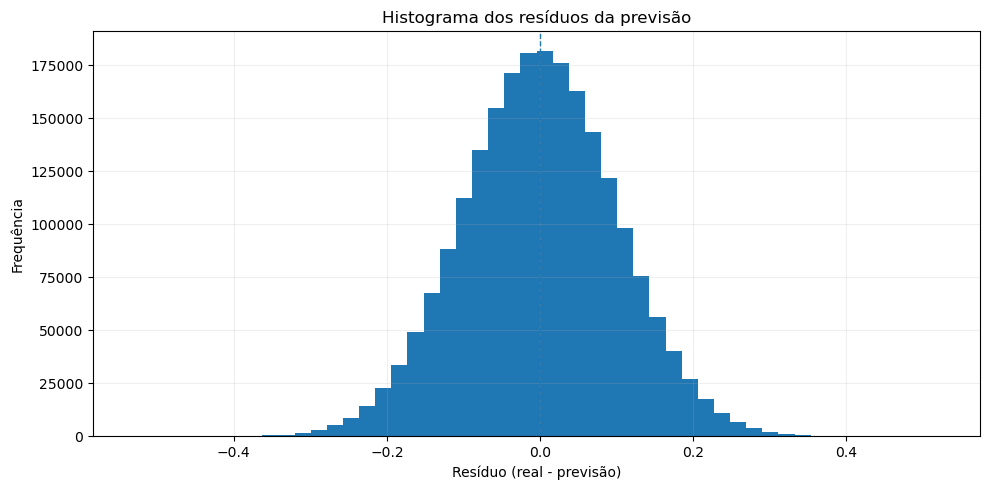

In [29]:
error_analyzer.plot_residual_histogram(
    bins=50
)

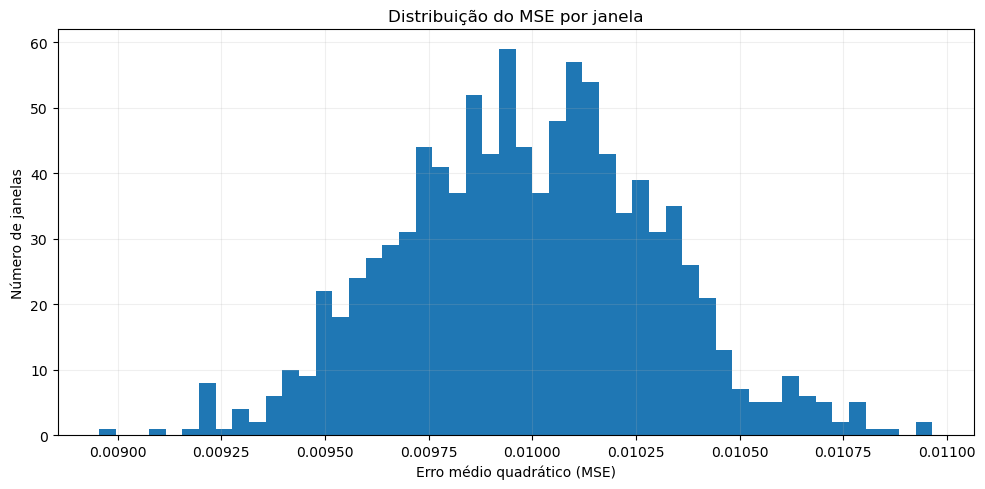

In [30]:
error_analyzer.plot_mse_histogram(
    bins=50
)

Caso decidisse salvar a imagem, basta definir o `save_path` na chamada do método:
```
error_analyzer.plot_residual_histogram(
    save_path="results/residual_histogram.png"
)
```

### 3. Testes

##### 3.1. Teste para resultado já calculado manualmente

Intuito: Comparar o resultado gerado pela classe para um caso simples com o histograma facilmente calculável manualmente.  

Erros definidos:  
(1 - 2)² = 1  
(2 - 2)² = 0  
(3 - 3)² = 0  
(4 - 6)² = 4  

Resultado esperado:  
MSE = (1 + 0 + 0 + 4) / 4 = 1.25

In [31]:
y_true_test = np.array(
    [
        [
            [1.0, 2.0],
            [3.0, 4.0],
        ]
    ],
    dtype=np.float32,
)

y_pred_test = np.array(
    [
        [
            [2.0, 2.0],
            [3.0, 6.0],
        ]
    ],
    dtype=np.float32,
)

In [32]:
test_analyzer = PredictionErrorAnalyzer(
    y_true=y_true_test,
    y_pred=y_pred_test,
)

test_mse = (
    test_analyzer
    .get_mse()
)

print(
    "MSE calculado:",
    test_mse[0],
)

assert np.isclose(
    test_mse[0],
    1.25,
)

print(
    "[OK] Cálculo do MSE validado."
)

MSE calculado: 1.25
[OK] Cálculo do MSE validado.


##### 3.2. Teste erro zero  
Teste para caso em que predição e real são iguais

In [33]:
y_true_zero = np.random.default_rng(
    123
).normal(
    size=(10, 128, 17)
).astype(np.float32)

y_pred_zero = y_true_zero.copy()

zero_test = PredictionErrorAnalyzer(
    y_true=y_true_zero,
    y_pred=y_pred_zero,
)

zero_mse = zero_test.get_mse()

print(
    "MSEs:",
    zero_mse
)

assert np.allclose(
    zero_mse,
    0.0,
)

print(
    "[OK] Previsão perfeita produz MSE = 0."
)

MSEs: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[OK] Previsão perfeita produz MSE = 0.


### 4. Validação final:

In [34]:
print(
    "=============================================="
)

print(
    " VALIDAÇÃO FINAL"
)

print(
    "=============================================="
)

assert y_true.shape == (
    N_WINDOWS,
    WINDOW_SIZE,
    N_VARIABLES,
)

assert y_pred.shape == y_true.shape

residuals = (
    error_analyzer
    .get_residuals()
)

mse = (
    error_analyzer
    .get_mse()
)

assert residuals.shape == y_true.shape

assert residuals.ndim == 3

assert mse.shape == (
    N_WINDOWS,
)

assert mse.ndim == 1

assert np.isfinite(
    residuals
).all()

assert np.isfinite(
    mse
).all()

assert (
    mse >= 0
).all()

print(
    f"Número de janelas: {N_WINDOWS}"
)

print(
    f"Window size:       {WINDOW_SIZE}"
)

print(
    f"Variáveis:          {N_VARIABLES}"
)

print(
    f"Shape da entrada:   {y_true.shape}"
)

print(
    f"Shape dos resíduos: {residuals.shape}"
)

print(
    f"Shape dos MSEs:     {mse.shape}"
)

print(
    f"NaN resíduos:       {np.isnan(residuals).sum()}"
)

print(
    f"Inf resíduos:       {np.isinf(residuals).sum()}"
)

print(
    f"NaN MSEs:            {np.isnan(mse).sum()}"
)

print(
    f"Inf MSEs:            {np.isinf(mse).sum()}"
)

print(
    "=============================================="
)

print(
    " PROTÓTIPO: PASSOU"
)

print(
    "=============================================="
)

 VALIDAÇÃO FINAL
Número de janelas: 1000
Window size:       128
Variáveis:          17
Shape da entrada:   (1000, 128, 17)
Shape dos resíduos: (1000, 128, 17)
Shape dos MSEs:     (1000,)
NaN resíduos:       0
Inf resíduos:       0
NaN MSEs:            0
Inf MSEs:            0
 PROTÓTIPO: PASSOU
